In [1]:
!pip install pandas mlxtend
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [2]:
#Loading the data
#File path variables

Local_path = 'C:/Users/beatr/OneDrive/Desktop/WGU/D212/Task 3/Data/'

InputFilePath = Local_path + 'teleco_market_basket.csv'
OutputfilePath =  Local_path + 'teleco_cleaned_df.csv'


teleco_df = pd.read_csv(InputFilePath)

In [3]:
teleco_df.head(100)

,Item01,Item02,Item03,Item04,Item05,Item06,Item07,Item08,Item09,Item10,Item11,Item12,Item13,Item14,Item15,Item16,Item17,Item18,Item19,Item20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Logitech M510 Wireless mouse,HP 63 Ink,HP 65 ink,nonda USB C to USB Adapter,10ft iPHone Charger Cable,HP 902XL ink,Creative Pebble 2.0 Speakers,Cleaning Gel Universal Dust Cleaner,Micro Center 32GB Memory card,YUNSONG 3pack 6ft Nylon Lightning Cable,TopMate C5 Laptop Cooler pad,Apple USB-C Charger cable,HyperX Cloud Stinger Headset,TONOR USB Gaming Microphone,Dust-Off Compressed Gas 2 pack,3A USB Type C Cable 3 pack 6FT,HOVAMP iPhone charger,SanDisk Ultra 128GB card,FEEL2NICE 5 pack 10ft Lighning cable,FEIYOLD Blue light Blocking Glasses
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Apple Lightning to Digital AV Adapter,TP-Link AC1750 Smart WiFi Router,Apple Pencil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Dust-Off Compressed Gas 2 pack,hP 65 Tri-color ink,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,HP 65 ink,M.2 Screw kit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
teleco_df.shape

(15002, 20)

In [5]:
teleco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15002 entries, 0 to 15001
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Item01  7501 non-null   object
 1   Item02  5747 non-null   object
 2   Item03  4389 non-null   object
 3   Item04  3345 non-null   object
 4   Item05  2529 non-null   object
 5   Item06  1864 non-null   object
 6   Item07  1369 non-null   object
 7   Item08  981 non-null    object
 8   Item09  654 non-null    object
 9   Item10  395 non-null    object
 10  Item11  256 non-null    object
 11  Item12  154 non-null    object
 12  Item13  87 non-null     object
 13  Item14  47 non-null     object
 14  Item15  25 non-null     object
 15  Item16  8 non-null      object
 16  Item17  4 non-null      object
 17  Item18  4 non-null      object
 18  Item19  3 non-null      object
 19  Item20  1 non-null      object
dtypes: object(20)
memory usage: 2.3+ MB


In [6]:
#Removing blank lines in the teleco market basket and resetting the index
teleco_cleaned_df=teleco_df.dropna(how='all').reset_index(drop=True)

In [7]:
teleco_cleaned_df.shape

(7501, 20)

In [8]:
teleco_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Item01  7501 non-null   object
 1   Item02  5747 non-null   object
 2   Item03  4389 non-null   object
 3   Item04  3345 non-null   object
 4   Item05  2529 non-null   object
 5   Item06  1864 non-null   object
 6   Item07  1369 non-null   object
 7   Item08  981 non-null    object
 8   Item09  654 non-null    object
 9   Item10  395 non-null    object
 10  Item11  256 non-null    object
 11  Item12  154 non-null    object
 12  Item13  87 non-null     object
 13  Item14  47 non-null     object
 14  Item15  25 non-null     object
 15  Item16  8 non-null      object
 16  Item17  4 non-null      object
 17  Item18  4 non-null      object
 18  Item19  3 non-null      object
 19  Item20  1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [9]:
teleco_cleaned_df.head()

,Item01,Item02,Item03,Item04,Item05,Item06,Item07,Item08,Item09,Item10,Item11,Item12,Item13,Item14,Item15,Item16,Item17,Item18,Item19,Item20
0,Logitech M510 Wireless mouse,HP 63 Ink,HP 65 ink,nonda USB C to USB Adapter,10ft iPHone Charger Cable,HP 902XL ink,Creative Pebble 2.0 Speakers,Cleaning Gel Universal Dust Cleaner,Micro Center 32GB Memory card,YUNSONG 3pack 6ft Nylon Lightning Cable,TopMate C5 Laptop Cooler pad,Apple USB-C Charger cable,HyperX Cloud Stinger Headset,TONOR USB Gaming Microphone,Dust-Off Compressed Gas 2 pack,3A USB Type C Cable 3 pack 6FT,HOVAMP iPhone charger,SanDisk Ultra 128GB card,FEEL2NICE 5 pack 10ft Lighning cable,FEIYOLD Blue light Blocking Glasses
1,Apple Lightning to Digital AV Adapter,TP-Link AC1750 Smart WiFi Router,Apple Pencil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UNEN Mfi Certified 5-pack Lightning Cable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Cat8 Ethernet Cable,HP 65 ink,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dust-Off Compressed Gas 2 pack,Screen Mom Screen Cleaner kit,Moread HDMI to VGA Adapter,HP 62XL Tri-Color ink,Apple USB-C Charger cable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
#An example of a transaction in the dataset
teleco_cleaned_df.iloc[0]

Item01               Logitech M510 Wireless mouse
Item02                                  HP 63 Ink
Item03                                  HP 65 ink
Item04                 nonda USB C to USB Adapter
Item05                  10ft iPHone Charger Cable
Item06                               HP 902XL ink
Item07               Creative Pebble 2.0 Speakers
Item08        Cleaning Gel Universal Dust Cleaner
Item09              Micro Center 32GB Memory card
Item10    YUNSONG 3pack 6ft Nylon Lightning Cable
Item11               TopMate C5 Laptop Cooler pad
Item12                  Apple USB-C Charger cable
Item13               HyperX Cloud Stinger Headset
Item14                TONOR USB Gaming Microphone
Item15             Dust-Off Compressed Gas 2 pack
Item16             3A USB Type C Cable 3 pack 6FT
Item17                      HOVAMP iPhone charger
Item18                   SanDisk Ultra 128GB card
Item19       FEEL2NICE 5 pack 10ft Lighning cable
Item20        FEIYOLD Blue light Blocking Glasses


In [11]:
#Convert rows to list of non-null items
basket = teleco_cleaned_df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
#Use TransactionEncoder to get one-hot encoded dataframe
encoder = TransactionEncoder()
transactions = encoder.fit(basket).transform(basket)
# Convert to DataFrame
teleco_basket_df = pd.DataFrame(transactions, columns=encoder.columns_)
teleco_basket_df.head()

,10ft iPHone Charger Cable,10ft iPHone Charger Cable 2 Pack,3 pack Nylon Braided Lightning Cable,3A USB Type C Cable 3 pack 6FT,5pack Nylon Braided USB C cables,ARRIS SURFboard SB8200 Cable Modem,Anker 2-in-1 USB Card Reader,Anker 4-port USB hub,Anker USB C to HDMI Adapter,Apple Lightning to Digital AV Adapter,...,hP 65 Tri-color ink,iFixit Pro Tech Toolkit,iPhone 11 case,iPhone 12 Charger cable,iPhone 12 Pro case,iPhone 12 case,iPhone Charger Cable Anker 6ft,iPhone SE case,nonda USB C to USB Adapter,seenda Wireless mouse
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
teleco_basket_df.iloc[0]

10ft iPHone Charger Cable                True
10ft iPHone Charger Cable 2 Pack        False
3 pack Nylon Braided Lightning Cable    False
3A USB Type C Cable 3 pack 6FT           True
5pack Nylon Braided USB C cables        False
                                        ...  
iPhone 12 case                          False
iPhone Charger Cable Anker 6ft          False
iPhone SE case                          False
nonda USB C to USB Adapter               True
seenda Wireless mouse                   False
Name: 0, Length: 119, dtype: bool

In [13]:
#creating the csv file of the cleaned dataset
teleco_basket_df.to_csv(OutputfilePath, index=False)


In [14]:
# Use the Apriori algorithm to find the frequent itemsets on the teleco_market basket
#Apriori is a classic algorithm in data mining used to find frequent itemsets (groups of items that often appear together) 
#and generate association rules from large datasets.Itemset is a collection of one or more items that appear together in transactions.
#include itemsets that appear in at least 2% of the transactions
#Return the actual item names
frequent_itemsets = apriori(teleco_basket_df, min_support = 0.02, use_colnames = True)
frequent_itemsets.sort_values(by='support',ascending=False).reset_index(drop=True)

,support,itemsets
0,0.238368,(Dust-Off Compressed Gas 2 pack)
1,0.179709,(Apple Pencil)
2,0.174110,(VIVO Dual LCD Monitor Desk mount)
3,0.170911,(USB 2.0 Printer cable)
4,0.163845,(HP 61 ink)
...,...,...
98,0.020397,(HP 63 Ink)
99,0.020264,"(SanDisk Ultra 128GB card, Dust-Off Compressed..."
100,0.020131,"(Dust-Off Compressed Gas 2 pack, Premium Nylon..."
101,0.020131,"(HP 62XL Tri-Color ink, Dust-Off Compressed Ga..."


In [15]:
#Generating association rules from the frequent itemset for items with a lift greater than 1
#Association rules are if-then statements that help discover interesting relationships between variables (items) in large datasets
#Lift Measures how much more likely the consequent is, given the antecedent, compared to chance.
#Lift > 1 → positive association (they occur together more than expected)
rules = association_rules(frequent_itemsets, metric = 'lift', min_threshold = 1)
rules=rules.sort_values(by='lift', ascending=False).reset_index(drop=True)
rules




,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(VIVO Dual LCD Monitor Desk mount),(SanDisk Ultra 64GB card),0.174110,0.098254,0.039195,0.225115,2.291162,1.0,0.022088,1.163716,0.682343,0.168096,0.140684,0.312015
1,(SanDisk Ultra 64GB card),(VIVO Dual LCD Monitor Desk mount),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
2,(FEIYOLD Blue light Blocking Glasses),(VIVO Dual LCD Monitor Desk mount),0.065858,0.174110,0.022930,0.348178,1.999758,1.0,0.011464,1.267048,0.535186,0.105651,0.210764,0.239939
3,(VIVO Dual LCD Monitor Desk mount),(FEIYOLD Blue light Blocking Glasses),0.174110,0.065858,0.022930,0.131700,1.999758,1.0,0.011464,1.075829,0.605334,0.105651,0.070484,0.239939
4,(Dust-Off Compressed Gas 2 pack),(10ft iPHone Charger Cable 2 Pack),0.238368,0.050527,0.023064,0.096756,1.914955,1.0,0.011020,1.051182,0.627330,0.086760,0.048690,0.276610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,(HP 61 ink),(Apple USB-C Charger cable),0.163845,0.132116,0.023464,0.143206,1.083943,1.0,0.001817,1.012944,0.092617,0.086106,0.012778,0.160402
90,(Apple Pencil),(Apple USB-C Charger cable),0.179709,0.132116,0.025463,0.141691,1.072479,1.0,0.001721,1.011156,0.082387,0.088920,0.011033,0.167213
91,(Apple USB-C Charger cable),(Apple Pencil),0.132116,0.179709,0.025463,0.192735,1.072479,1.0,0.001721,1.016135,0.077869,0.088920,0.015879,0.167213
92,(Screen Mom Screen Cleaner kit),(USB 2.0 Printer cable),0.129583,0.170911,0.023730,0.183128,1.071482,1.0,0.001583,1.014956,0.076645,0.085742,0.014735,0.160987


In [16]:
print("Rules identified:", len(rules))

Rules identified: 94


In [17]:
rules_table = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
#pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
print(rules_table)

                              antecedents  \
0      (VIVO Dual LCD Monitor Desk mount)   
1               (SanDisk Ultra 64GB card)   
2   (FEIYOLD Blue light Blocking Glasses)   
3      (VIVO Dual LCD Monitor Desk mount)   
4        (Dust-Off Compressed Gas 2 pack)   
..                                    ...   
89                            (HP 61 ink)   
90                         (Apple Pencil)   
91            (Apple USB-C Charger cable)   
92        (Screen Mom Screen Cleaner kit)   
93                (USB 2.0 Printer cable)   

                              consequents   support  confidence      lift  
0               (SanDisk Ultra 64GB card)  0.039195    0.225115  2.291162  
1      (VIVO Dual LCD Monitor Desk mount)  0.039195    0.398915  2.291162  
2      (VIVO Dual LCD Monitor Desk mount)  0.022930    0.348178  1.999758  
3   (FEIYOLD Blue light Blocking Glasses)  0.022930    0.131700  1.999758  
4      (10ft iPHone Charger Cable 2 Pack)  0.023064    0.096756  1.914955  
.. 

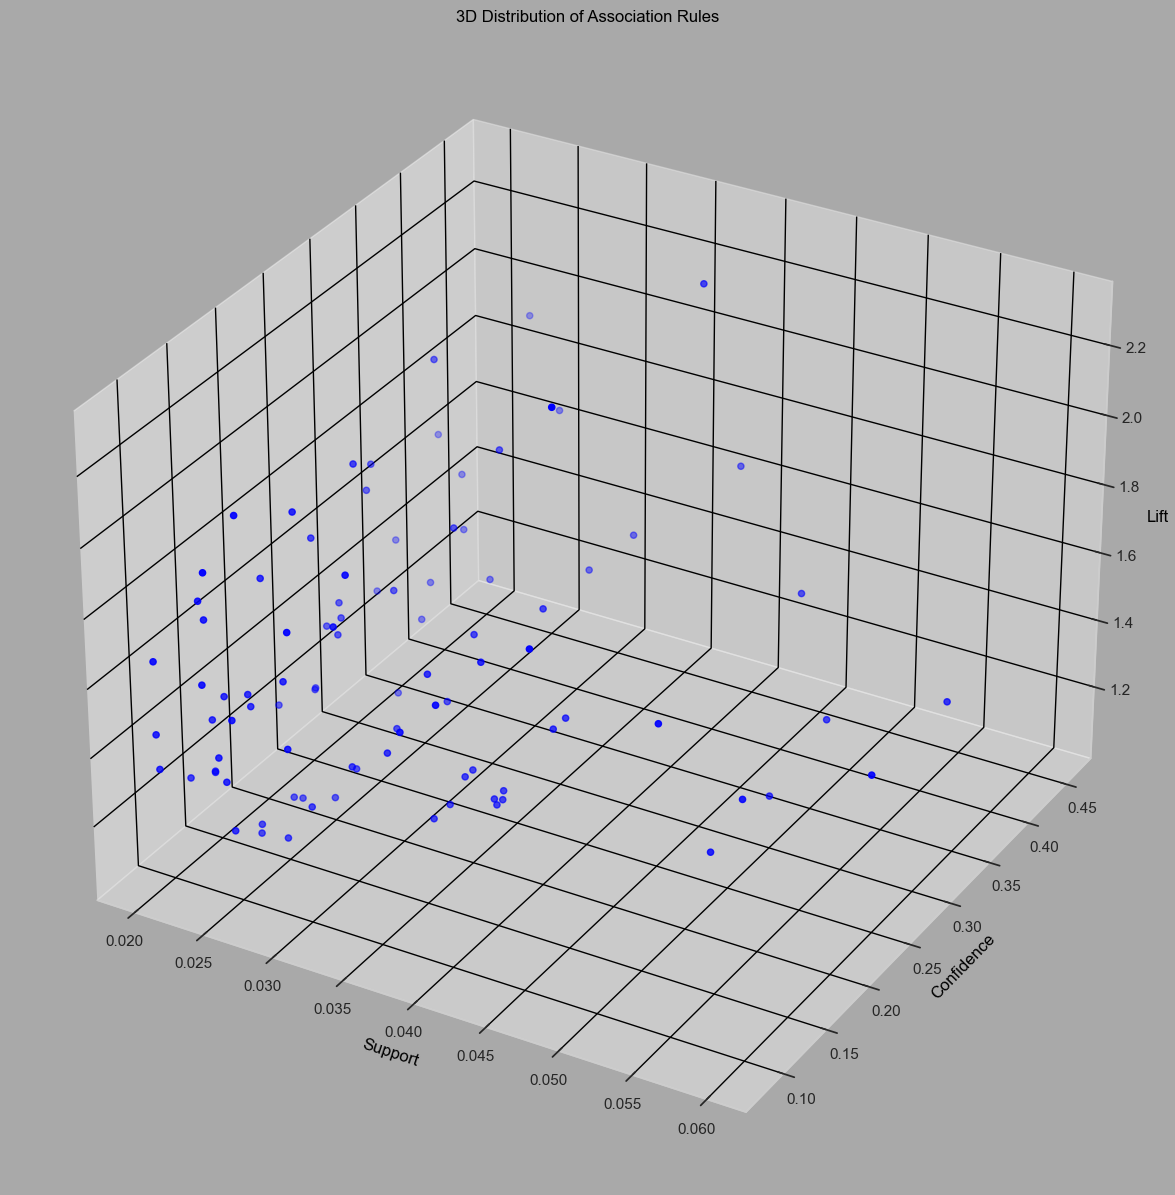

In [41]:
#Visualization 
#Code source: Lim, Yenwee (2022, April 8) Data Mining: Market Basket Analysis with Apriori Algorithm: Visualizations
#  https://towardsdatascience.com/data-mining-market-basket-analysis-with-apriori-algorithm-970ff256a92c/

sns.set(style="whitegrid")
fig = plt.figure(figsize=(15, 15), facecolor='darkgray')
ax = fig.add_subplot(projection='3d')
x = rules['support']
y = rules['confidence']
z = rules['lift']
ax.set_facecolor('darkgray')
ax.xaxis._axinfo["grid"]['color'] = "black"
ax.yaxis._axinfo["grid"]['color'] = "black"
ax.zaxis._axinfo["grid"]['color'] = "black"
ax.set_xlabel("Support", color='black')
ax.set_ylabel("Confidence", color='black')
ax.set_zlabel("Lift", color='black')
ax.set_title("3D Distribution of Association Rules", color='black')

ax.scatter(x, y, z, color='blue')
plt.show()

In [19]:
#sorting the data on the basis of highest confidence
#confidence The likelihood that a rule is correct. 
#confidence  tells you how often the consequent is true when the antecedent is true.
rules=rules.sort_values(by='confidence', ascending=False).reset_index(drop=True)
rules.head(6)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(10ft iPHone Charger Cable 2 Pack),(Dust-Off Compressed Gas 2 pack),0.050527,0.238368,0.023064,0.456464,1.914955,1.0,0.011020,1.401255,0.503221,0.086760,0.286354,0.276610
1,(FEIYOLD Blue light Blocking Glasses),(Dust-Off Compressed Gas 2 pack),0.065858,0.238368,0.027596,0.419028,1.757904,1.0,0.011898,1.310962,0.461536,0.099759,0.237201,0.267400
2,(SanDisk Ultra 64GB card),(Dust-Off Compressed Gas 2 pack),0.098254,0.238368,0.040928,0.416554,1.747522,1.0,0.017507,1.305401,0.474369,0.138413,0.233952,0.294127
3,(SanDisk Ultra 64GB card),(VIVO Dual LCD Monitor Desk mount),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
4,(Premium Nylon USB Cable),(Dust-Off Compressed Gas 2 pack),0.051060,0.238368,0.020131,0.394256,1.653978,1.0,0.007960,1.257349,0.416672,0.074752,0.204676,0.239354
5,(Falcon Dust Off Compressed Gas),(Dust-Off Compressed Gas 2 pack),0.059992,0.238368,0.022797,0.380000,1.594172,1.0,0.008497,1.228438,0.396502,0.082729,0.185958,0.237819


In [20]:
#sorting the data on the basis of highest support
#Support is the proportion of transactions that contain a certain itemset.
rules=rules.sort_values(by='support', ascending=False).reset_index(drop=True)
rules.head(6)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Dust-Off Compressed Gas 2 pack),(VIVO Dual LCD Monitor Desk mount),0.238368,0.174110,0.059725,0.250559,1.439085,1.0,0.018223,1.102008,0.400606,0.169312,0.092566,0.296796
1,(VIVO Dual LCD Monitor Desk mount),(Dust-Off Compressed Gas 2 pack),0.174110,0.238368,0.059725,0.343032,1.439085,1.0,0.018223,1.159314,0.369437,0.169312,0.137421,0.296796
2,(Dust-Off Compressed Gas 2 pack),(HP 61 ink),0.238368,0.163845,0.052660,0.220917,1.348332,1.0,0.013604,1.073256,0.339197,0.150648,0.068256,0.271158
3,(HP 61 ink),(Dust-Off Compressed Gas 2 pack),0.163845,0.238368,0.052660,0.321400,1.348332,1.0,0.013604,1.122357,0.308965,0.150648,0.109018,0.271158
4,(Apple Pencil),(Dust-Off Compressed Gas 2 pack),0.179709,0.238368,0.050927,0.283383,1.188845,1.0,0.008090,1.062815,0.193648,0.138707,0.059103,0.248515
5,(Dust-Off Compressed Gas 2 pack),(Apple Pencil),0.238368,0.179709,0.050927,0.213647,1.188845,1.0,0.008090,1.043158,0.208562,0.138707,0.041372,0.248515


In [21]:
#top three relevant rules generated by the Apriori algorithm where lift is greater thab 1.9 showing a strong association,
#with a confidence of 0.3

top_3_rules = rules[(rules['lift'] > 1.9) & (rules['confidence'] > 0.3)].sort_values(by=['lift'], ascending= False)
top_3_rules.reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(SanDisk Ultra 64GB card),(VIVO Dual LCD Monitor Desk mount),0.098254,0.174110,0.039195,0.398915,2.291162,1.0,0.022088,1.373997,0.624943,0.168096,0.272197,0.312015
1,(FEIYOLD Blue light Blocking Glasses),(VIVO Dual LCD Monitor Desk mount),0.065858,0.174110,0.022930,0.348178,1.999758,1.0,0.011464,1.267048,0.535186,0.105651,0.210764,0.239939
2,(10ft iPHone Charger Cable 2 Pack),(Dust-Off Compressed Gas 2 pack),0.050527,0.238368,0.023064,0.456464,1.914955,1.0,0.011020,1.401255,0.503221,0.086760,0.286354,0.276610


In [22]:
#finding the antecedent itemsets that are most common in the rules
#The antecedent is the “if” part of an association rule. 
#antecedent the item or group of items that come before the arrow (→) in a rule

rules.antecedents.value_counts()

antecedents
(Dust-Off Compressed Gas 2 pack)           18
(VIVO Dual LCD Monitor Desk mount)         12
(Apple Pencil)                              9
(HP 61 ink)                                 8
(Screen Mom Screen Cleaner kit)             7
(USB 2.0 Printer cable)                     6
(Nylon Braided Lightning to USB cable)      5
(Apple Lightning to Digital AV Adapter)     4
(Apple USB-C Charger cable)                 4
(Stylus Pen for iPad)                       4
(SanDisk Ultra 64GB card)                   4
(FEIYOLD Blue light Blocking Glasses)       2
(Anker USB C to HDMI Adapter)               2
(Logitech M510 Wireless mouse)              2
(Syntech USB C to USB Adapter)              1
(TopMate C5 Laptop Cooler pad)              1
(10ft iPHone Charger Cable 2 Pack)          1
(Falcon Dust Off Compressed Gas)            1
(SanDisk Ultra 128GB card)                  1
(HP 62XL Tri-Color ink)                     1
(Premium Nylon USB Cable)                   1
Name: count, dtype: in

In [23]:
#finding the consequent itemsets that are most common in the rules
#The consequent is the “then” part of an association rule. 
#consequent is the item or group of items that come after the arrow (→) in a rule.
rules.consequents.value_counts()

consequents
(Dust-Off Compressed Gas 2 pack)           18
(VIVO Dual LCD Monitor Desk mount)         12
(Apple Pencil)                              9
(HP 61 ink)                                 8
(Screen Mom Screen Cleaner kit)             7
(USB 2.0 Printer cable)                     6
(Nylon Braided Lightning to USB cable)      5
(Apple Lightning to Digital AV Adapter)     4
(Apple USB-C Charger cable)                 4
(Stylus Pen for iPad)                       4
(SanDisk Ultra 64GB card)                   4
(FEIYOLD Blue light Blocking Glasses)       2
(Anker USB C to HDMI Adapter)               2
(Logitech M510 Wireless mouse)              2
(Syntech USB C to USB Adapter)              1
(TopMate C5 Laptop Cooler pad)              1
(10ft iPHone Charger Cable 2 Pack)          1
(Falcon Dust Off Compressed Gas)            1
(SanDisk Ultra 128GB card)                  1
(Premium Nylon USB Cable)                   1
(HP 62XL Tri-Color ink)                     1
Name: count, dtype: in

In [24]:
#getting all rules that involve Apple Pencil either as antecedent or consequent
ant_df = rules[rules['antecedents'] == {'Apple Pencil'}]
con_df = rules[rules['consequents'] == {'Apple Pencil'}]
ApplePencil_df = pd.concat([ant_df, con_df])
ApplePencil_df.sort_values(by='confidence', ascending=False).reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Apple Lightning to Digital AV Adapter),(Apple Pencil),0.087188,0.179709,0.028796,0.330275,1.837830,1.0,0.013128,1.224818,0.499424,0.120941,0.183552,0.245256
1,(Apple Pencil),(Dust-Off Compressed Gas 2 pack),0.179709,0.238368,0.050927,0.283383,1.188845,1.0,0.008090,1.062815,0.193648,0.138707,0.059103,0.248515
2,(Screen Mom Screen Cleaner kit),(Apple Pencil),0.129583,0.179709,0.030796,0.237654,1.322437,1.0,0.007509,1.076009,0.280119,0.110579,0.070640,0.204510
3,(Stylus Pen for iPad),(Apple Pencil),0.095054,0.179709,0.021730,0.228612,1.272118,1.0,0.004648,1.063395,0.236378,0.085880,0.059616,0.174766
4,(Nylon Braided Lightning to USB cable),(Apple Pencil),0.095321,0.179709,0.021730,0.227972,1.268559,1.0,0.004600,1.062514,0.234010,0.085789,0.058836,0.174446
5,(Dust-Off Compressed Gas 2 pack),(Apple Pencil),0.238368,0.179709,0.050927,0.213647,1.188845,1.0,0.008090,1.043158,0.208562,0.138707,0.041372,0.248515
6,(USB 2.0 Printer cable),(Apple Pencil),0.170911,0.179709,0.036395,0.212949,1.184961,1.0,0.005681,1.042232,0.188267,0.115825,0.040521,0.207735
7,(VIVO Dual LCD Monitor Desk mount),(Apple Pencil),0.174110,0.179709,0.036528,0.209801,1.167446,1.0,0.005239,1.038081,0.173666,0.115126,0.036684,0.206533
8,(Apple Pencil),(VIVO Dual LCD Monitor Desk mount),0.179709,0.174110,0.036528,0.203264,1.167446,1.0,0.005239,1.036592,0.174852,0.115126,0.035300,0.206533
9,(HP 61 ink),(Apple Pencil),0.163845,0.179709,0.033196,0.202604,1.127397,1.0,0.003751,1.028711,0.135143,0.106959,0.027910,0.193661


In [25]:
print("Rules identified:", len(ApplePencil_df))

Rules identified: 18


In [26]:
ApplePencil_df.sort_values(by='lift', ascending=False).reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Apple Lightning to Digital AV Adapter),(Apple Pencil),0.087188,0.179709,0.028796,0.330275,1.837830,1.0,0.013128,1.224818,0.499424,0.120941,0.183552,0.245256
1,(Apple Pencil),(Apple Lightning to Digital AV Adapter),0.179709,0.087188,0.028796,0.160237,1.837830,1.0,0.013128,1.086988,0.555754,0.120941,0.080026,0.245256
2,(Apple Pencil),(Screen Mom Screen Cleaner kit),0.179709,0.129583,0.030796,0.171365,1.322437,1.0,0.007509,1.050423,0.297236,0.110579,0.048003,0.204510
3,(Screen Mom Screen Cleaner kit),(Apple Pencil),0.129583,0.179709,0.030796,0.237654,1.322437,1.0,0.007509,1.076009,0.280119,0.110579,0.070640,0.204510
4,(Stylus Pen for iPad),(Apple Pencil),0.095054,0.179709,0.021730,0.228612,1.272118,1.0,0.004648,1.063395,0.236378,0.085880,0.059616,0.174766
5,(Apple Pencil),(Stylus Pen for iPad),0.179709,0.095054,0.021730,0.120920,1.272118,1.0,0.004648,1.029424,0.260773,0.085880,0.028583,0.174766
6,(Nylon Braided Lightning to USB cable),(Apple Pencil),0.095321,0.179709,0.021730,0.227972,1.268559,1.0,0.004600,1.062514,0.234010,0.085789,0.058836,0.174446
7,(Apple Pencil),(Nylon Braided Lightning to USB cable),0.179709,0.095321,0.021730,0.120920,1.268559,1.0,0.004600,1.029121,0.258084,0.085789,0.028296,0.174446
8,(Apple Pencil),(Dust-Off Compressed Gas 2 pack),0.179709,0.238368,0.050927,0.283383,1.188845,1.0,0.008090,1.062815,0.193648,0.138707,0.059103,0.248515
9,(Dust-Off Compressed Gas 2 pack),(Apple Pencil),0.238368,0.179709,0.050927,0.213647,1.188845,1.0,0.008090,1.043158,0.208562,0.138707,0.041372,0.248515


In [27]:
ApplePencil_df.sort_values(by='support', ascending=False).reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Apple Pencil),(Dust-Off Compressed Gas 2 pack),0.179709,0.238368,0.050927,0.283383,1.188845,1.0,0.008090,1.062815,0.193648,0.138707,0.059103,0.248515
1,(Dust-Off Compressed Gas 2 pack),(Apple Pencil),0.238368,0.179709,0.050927,0.213647,1.188845,1.0,0.008090,1.043158,0.208562,0.138707,0.041372,0.248515
2,(Apple Pencil),(VIVO Dual LCD Monitor Desk mount),0.179709,0.174110,0.036528,0.203264,1.167446,1.0,0.005239,1.036592,0.174852,0.115126,0.035300,0.206533
3,(VIVO Dual LCD Monitor Desk mount),(Apple Pencil),0.174110,0.179709,0.036528,0.209801,1.167446,1.0,0.005239,1.038081,0.173666,0.115126,0.036684,0.206533
4,(Apple Pencil),(USB 2.0 Printer cable),0.179709,0.170911,0.036395,0.202522,1.184961,1.0,0.005681,1.039640,0.190286,0.115825,0.038128,0.207735
5,(USB 2.0 Printer cable),(Apple Pencil),0.170911,0.179709,0.036395,0.212949,1.184961,1.0,0.005681,1.042232,0.188267,0.115825,0.040521,0.207735
6,(Apple Pencil),(HP 61 ink),0.179709,0.163845,0.033196,0.184718,1.127397,1.0,0.003751,1.025603,0.137757,0.106959,0.024963,0.193661
7,(HP 61 ink),(Apple Pencil),0.163845,0.179709,0.033196,0.202604,1.127397,1.0,0.003751,1.028711,0.135143,0.106959,0.027910,0.193661
8,(Apple Pencil),(Screen Mom Screen Cleaner kit),0.179709,0.129583,0.030796,0.171365,1.322437,1.0,0.007509,1.050423,0.297236,0.110579,0.048003,0.204510
9,(Screen Mom Screen Cleaner kit),(Apple Pencil),0.129583,0.179709,0.030796,0.237654,1.322437,1.0,0.007509,1.076009,0.280119,0.110579,0.070640,0.204510
